In [2]:
# Import all required packages
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import os
import random
from collections import Counter
from sklearn.cluster import KMeans
import pandas as pd

In [3]:
# ============================================
# FUNCTIONS
# ============================================

def load_image(path):
    img = Image.open(path)
    img_array = np.array(img)
    if len(img_array.shape) == 3 and img_array.shape[2] == 4:
        img_array = img_array[:, :, :3]
    return img_array

def crop_border(img_array, tolerance=20):
    h, w = img_array.shape[:2]
    corners = [img_array[0,0], img_array[0,w-1], img_array[h-1,0], img_array[h-1,w-1]]
    border_color = np.mean(corners, axis=0).astype(np.uint8)
    
    def is_border(pixel):
        return np.all(np.abs(pixel.astype(int) - border_color.astype(int)) <= tolerance)
    def is_border_line(line, threshold=0.9):
        return sum(1 for p in line if is_border(p)) / len(line) > threshold
    
    top, bottom, left, right = 0, h-1, 0, w-1
    for i in range(h):
        if not is_border_line(img_array[i, :]): top = i; break
    for i in range(h-1, -1, -1):
        if not is_border_line(img_array[i, :]): bottom = i; break
    for j in range(w):
        if not is_border_line(img_array[:, j]): left = j; break
    for j in range(w-1, -1, -1):
        if not is_border_line(img_array[:, j]): right = j; break
    
    return img_array[top:bottom+1, left:right+1], border_color, (top, bottom, left, right)

def kmeans_cluster(img_array, k, border_color, tolerance=20):
    pixels = img_array.reshape(-1, 3)
    def is_border(p):
        return np.all(np.abs(p.astype(int) - border_color.astype(int)) <= tolerance)
    
    non_border_mask = np.array([not is_border(p) for p in pixels])
    non_border_pixels = pixels[non_border_mask]
    
    if len(non_border_pixels) == 0:
        return np.full(len(pixels), -1), np.zeros((k, 3), dtype=np.uint8)
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(non_border_pixels)
    
    labels = np.full(len(pixels), -1)
    labels[non_border_mask] = kmeans.predict(non_border_pixels)
    
    return labels, kmeans.cluster_centers_.astype(np.uint8)

def generate_random_colors(k):
    colors = []
    for i in range(k):
        hue = int(180 * i / k)
        hsv = np.uint8([[[hue, 255, 255]]])
        rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)[0][0]
        colors.append(tuple(rgb))
    return colors

def create_clustered_image(shape, labels, random_colors):
    h, w = shape[:2]
    random_img = np.zeros((h*w, 3), dtype=np.uint8)
    for i in range(h*w):
        if labels[i] >= 0:
            random_img[i] = random_colors[labels[i]]
    return random_img.reshape(h, w, 3)

def fill_holes(img, box_sizes=[3, 5, 7, 11, 15]):
    filled = img.copy()
    h, w = img.shape[:2]
    black_mask = np.all(filled <= 10, axis=2)
    positions = list(zip(*np.where(black_mask)))
    cx, cy = h // 2, w // 2
    positions.sort(key=lambda p: (p[0]-cx)**2 + (p[1]-cy)**2)
    
    for i, j in positions:
        for box in box_sizes:
            half = box // 2
            t, b = max(0, i-half), min(h, i+half+1)
            l, r = max(0, j-half), min(w, j+half+1)
            neighborhood = filled[t:b, l:r].reshape(-1, 3)
            non_black = [tuple(p) for p in neighborhood if np.any(p > 10)]
            if non_black:
                filled[i, j] = Counter(non_black).most_common(1)[0][0]
                break
    return filled

def restore_to_original_shape(processed_img, original_shape, crop_bounds):
    top, bottom, left, right = crop_bounds
    h, w = original_shape[:2]
    restored = np.zeros((h, w, 3), dtype=np.uint8)
    restored[top:bottom+1, left:right+1] = processed_img
    return restored

def process_image(input_path, output_path, k=10):
    original = load_image(input_path)
    cropped, border_color, crop_bounds = crop_border(original)
    labels, centers = kmeans_cluster(cropped, k, border_color)
    random_colors = generate_random_colors(k)
    kmeans_rand = create_clustered_image(cropped.shape, labels, random_colors)
    filled = fill_holes(kmeans_rand)
    restored = restore_to_original_shape(filled, original.shape, crop_bounds)
    Image.fromarray(restored).save(output_path)
    return restored

print("Functions loaded!")

Functions loaded!


In [4]:
# ============================================
# BATCH PROCESS - SET K HERE
# ============================================

K = 9   # <-- CHANGE THIS VALUE
RUN_PROCESSING = False  # <-- SET TO True TO REPROCESS

if RUN_PROCESSING:
    input_folder = 'subi'
    output_folder = 'subcolr'
    os.makedirs(output_folder, exist_ok=True)
    
    images = sorted([f for f in os.listdir(input_folder) if f.endswith('.png')], 
                    key=lambda x: int(x.split('.')[0]))
    
    print(f"Processing {len(images)} images with K={K}...")
    for i, img_name in enumerate(images):
        input_path = os.path.join(input_folder, img_name)
        output_path = os.path.join(output_folder, img_name)
        process_image(input_path, output_path, K)
        print(f"[{i+1}/{len(images)}] Processed {img_name}")
    print(f"\nDone! Saved {len(images)} images to {output_folder}/")
else:
    print(f"Processing SKIPPED. Set RUN_PROCESSING = True to reprocess with K={K}")

Processing SKIPPED. Set RUN_PROCESSING = True to reprocess with K=9


Randomly selected images: ['14', '3', '19', '24', '18']



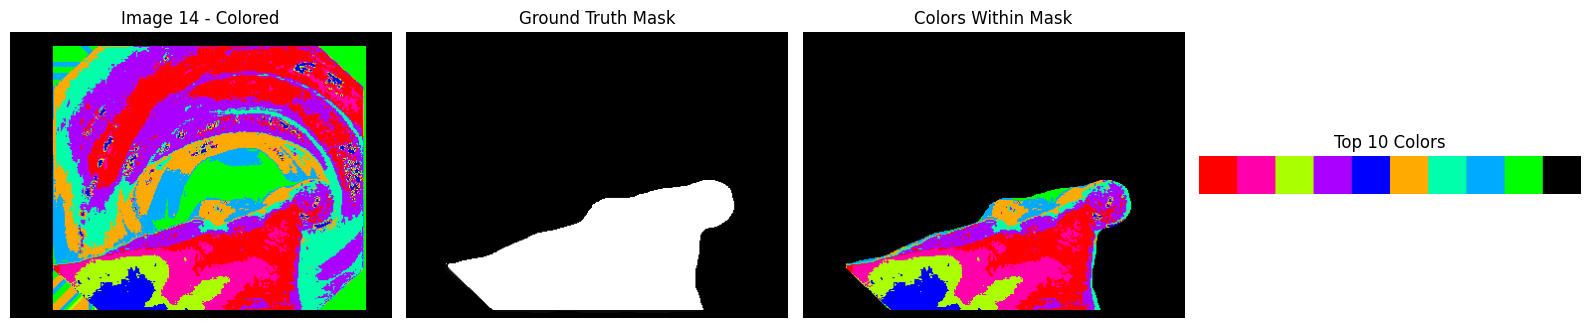


=== Image 14 - Frequency Map (within white mask) ===
Total masked pixels: 23199
Unique colors: 10
          RGB  Frequency  Percentage
  (255, 0, 0)       6020       25.95
(255, 0, 170)       4676       20.16
(170, 255, 0)       3540       15.26
(170, 0, 255)       3348       14.43
  (0, 0, 255)       1966        8.47
(255, 170, 0)       1268        5.47
(0, 255, 170)       1179        5.08
(0, 170, 255)        903        3.89
  (0, 255, 0)        295        1.27
    (0, 0, 0)          4        0.02

>>> TOP 3 COLORS COMBINED: 61.37%



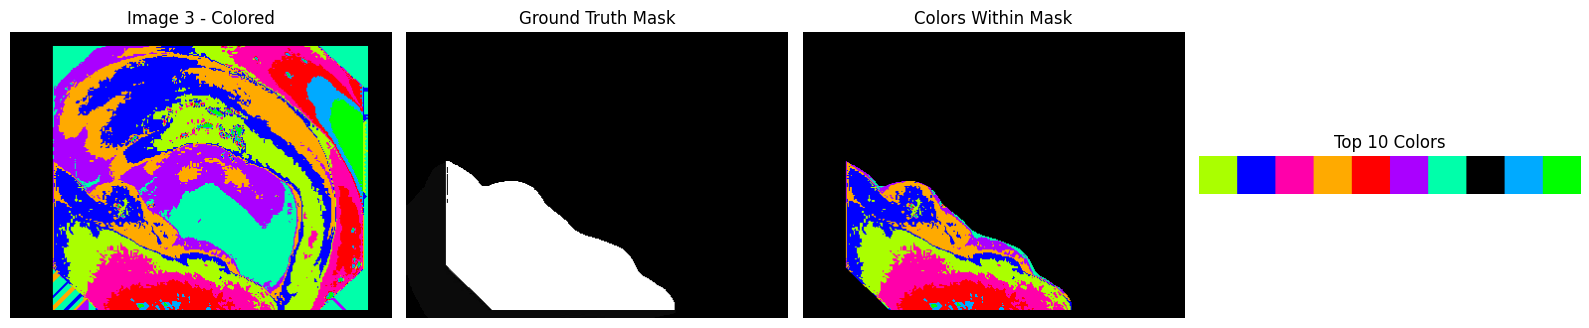


=== Image 3 - Frequency Map (within white mask) ===
Total masked pixels: 19996
Unique colors: 10
          RGB  Frequency  Percentage
(170, 255, 0)       4616       23.08
  (0, 0, 255)       4315       21.58
(255, 0, 170)       3964       19.82
(255, 170, 0)       2827       14.14
  (255, 0, 0)       2473       12.37
(170, 0, 255)        919        4.60
(0, 255, 170)        318        1.59
    (0, 0, 0)        287        1.44
(0, 170, 255)        241        1.21
  (0, 255, 0)         36        0.18

>>> TOP 3 COLORS COMBINED: 64.48%



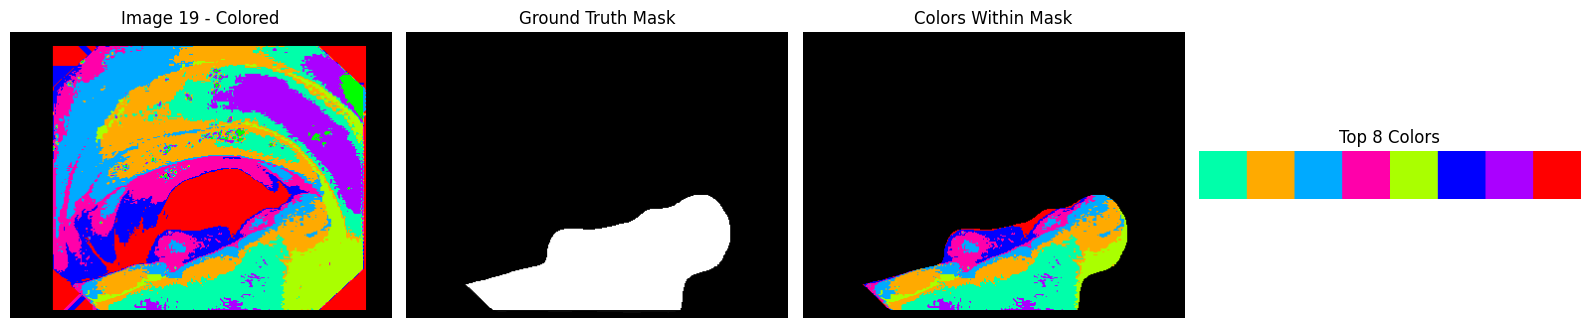


=== Image 19 - Frequency Map (within white mask) ===
Total masked pixels: 18092
Unique colors: 8
          RGB  Frequency  Percentage
(0, 255, 170)       5681       31.40
(255, 170, 0)       4404       24.34
(0, 170, 255)       2367       13.08
(255, 0, 170)       1822       10.07
(170, 255, 0)       1559        8.62
  (0, 0, 255)       1341        7.41
(170, 0, 255)        519        2.87
  (255, 0, 0)        399        2.21

>>> TOP 3 COLORS COMBINED: 68.82%



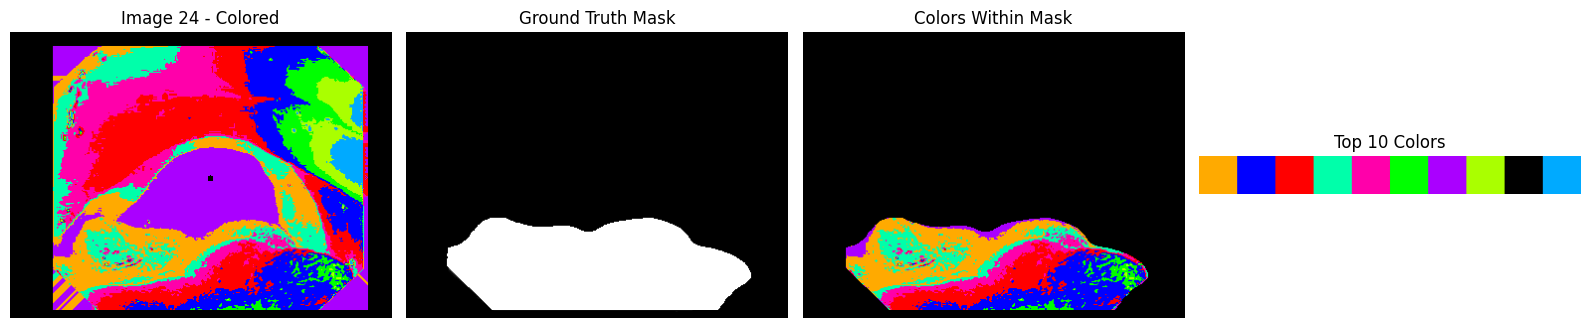


=== Image 24 - Frequency Map (within white mask) ===
Total masked pixels: 22692
Unique colors: 10
          RGB  Frequency  Percentage
(255, 170, 0)       5972       26.32
  (0, 0, 255)       4843       21.34
  (255, 0, 0)       3904       17.20
(0, 255, 170)       3549       15.64
(255, 0, 170)       2373       10.46
  (0, 255, 0)       1094        4.82
(170, 0, 255)        865        3.81
(170, 255, 0)         58        0.26
    (0, 0, 0)         31        0.14
(0, 170, 255)          3        0.01

>>> TOP 3 COLORS COMBINED: 64.86%



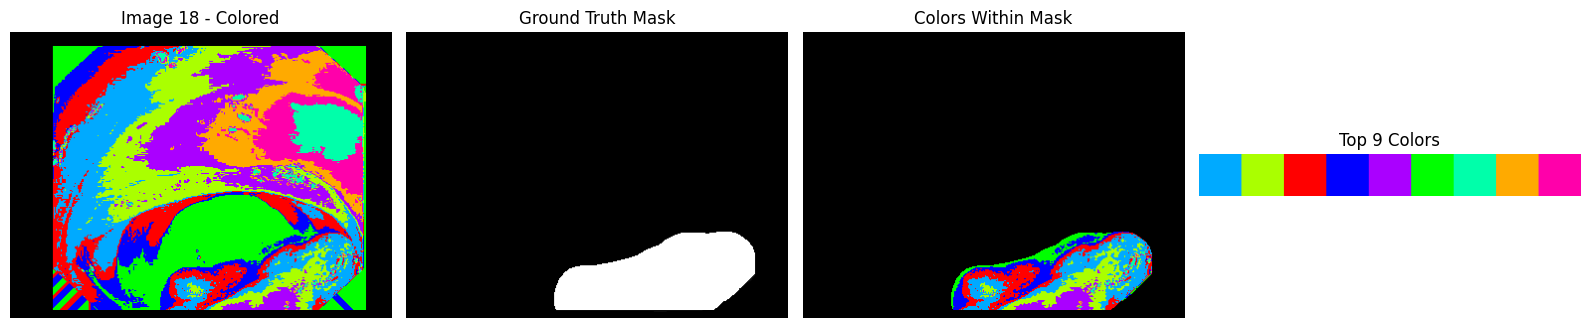


=== Image 18 - Frequency Map (within white mask) ===
Total masked pixels: 11657
Unique colors: 9
          RGB  Frequency  Percentage
(0, 170, 255)       3530       30.28
(170, 255, 0)       2219       19.04
  (255, 0, 0)       2214       18.99
  (0, 0, 255)       1574       13.50
(170, 0, 255)       1012        8.68
  (0, 255, 0)        942        8.08
(0, 255, 170)        101        0.87
(255, 170, 0)         35        0.30
(255, 0, 170)         30        0.26

>>> TOP 3 COLORS COMBINED: 68.31%



In [5]:
# ============================================
# FREQUENCY MAP - RANDOM 5 IMAGES
# ============================================

# Get all available images and pick 5 random
all_images = [str(i) for i in range(1, 31)]
image_ids = random.sample(all_images, 5)
print(f"Randomly selected images: {image_ids}\n")

for img_id in image_ids:
    colored = load_image(f'subcolr/{img_id}.png')
    gt = load_image(f'subgt/{img_id}.png')
    
    if len(gt.shape) == 3:
        white_mask = np.all(gt > 200, axis=2)
    else:
        white_mask = gt > 200
    
    masked_pixels = colored[white_mask]
    pixel_tuples = [tuple(p) for p in masked_pixels]
    freq_map = Counter(pixel_tuples)
    
    freq_df = pd.DataFrame(
        [(rgb, count) for rgb, count in freq_map.most_common()],
        columns=['RGB', 'Frequency']
    )
    freq_df['Percentage'] = (freq_df['Frequency'] / len(masked_pixels) * 100).round(2)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(colored)
    axes[0].set_title(f'Image {img_id} - Colored')
    axes[0].axis('off')
    
    axes[1].imshow(gt, cmap='gray')
    axes[1].set_title(f'Ground Truth Mask')
    axes[1].axis('off')
    
    masked_view = np.zeros_like(colored)
    masked_view[white_mask] = colored[white_mask]
    axes[2].imshow(masked_view)
    axes[2].set_title(f'Colors Within Mask')
    axes[2].axis('off')
    
    top_colors = freq_df.head(10)
    color_bar = np.zeros((50, len(top_colors)*50, 3), dtype=np.uint8)
    for i, (rgb, _, _) in enumerate(top_colors.values):
        color_bar[:, i*50:(i+1)*50] = rgb
    axes[3].imshow(color_bar)
    axes[3].set_title(f'Top {len(top_colors)} Colors')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n=== Image {img_id} - Frequency Map (within white mask) ===")
    print(f"Total masked pixels: {len(masked_pixels)}")
    print(f"Unique colors: {len(freq_map)}")
    print(freq_df.head(10).to_string(index=False))
    
    top3_sum = freq_df.head(3)['Percentage'].sum()
    print(f"\n>>> TOP 3 COLORS COMBINED: {top3_sum:.2f}%")
    print()

Visualizing transformation steps for: 23.png


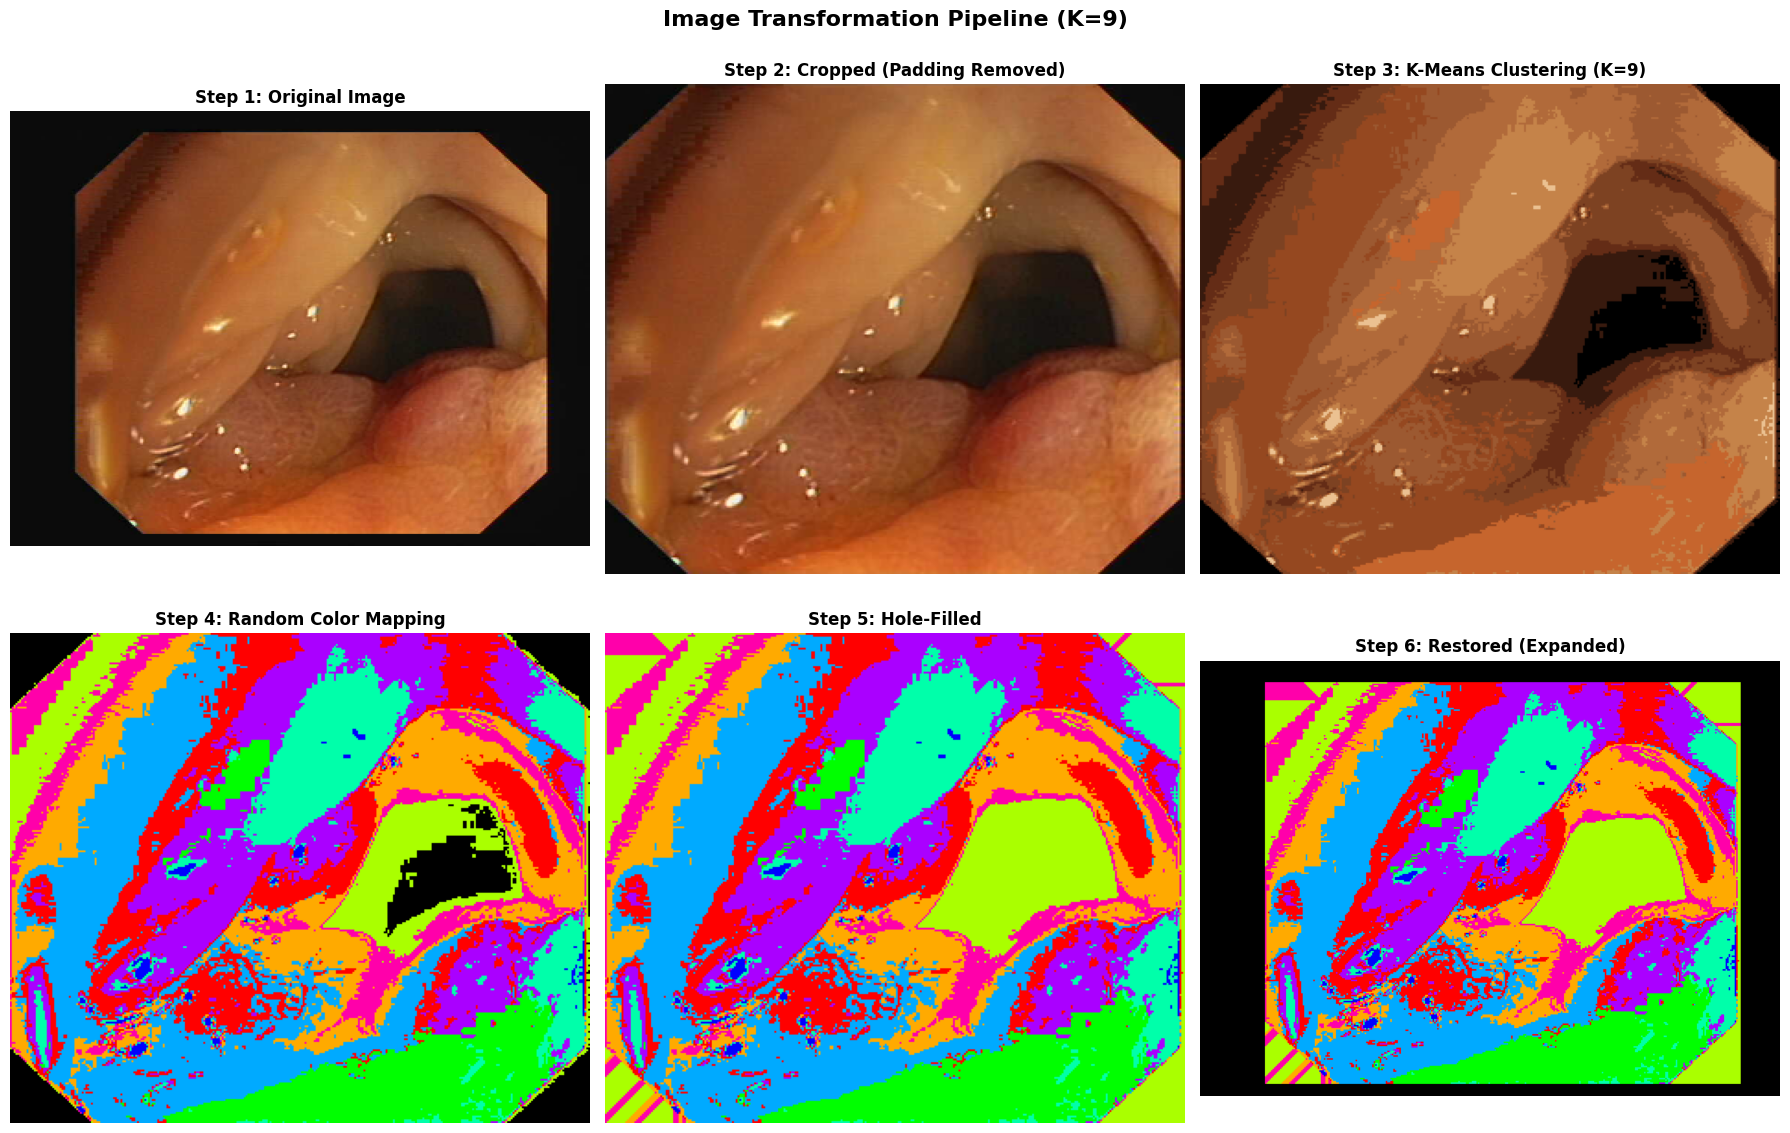


Transformation pipeline visualization saved to: transformation_steps.png


In [6]:
# ============================================
# VISUALIZE ALL TRANSFORMATION STEPS
# ============================================

def visualize_transformation_steps(input_path, k=9):
    """
    Visualize all steps of the image transformation pipeline:
    1. Original Image
    2. Cropped (Padding Removed)
    3. K-Means Clustering (with original cluster colors)
    4. Colored Clusters (with random distinct colors)
    5. Hole-Filled
    6. Restored to Original Size
    """
    # Step 1: Load original image
    original = load_image(input_path)
    
    # Step 2: Crop border / remove padding
    cropped, border_color, crop_bounds = crop_border(original)
    
    # Step 3: K-Means clustering
    labels, centers = kmeans_cluster(cropped, k, border_color)
    
    # Create image with original cluster center colors
    h, w = cropped.shape[:2]
    kmeans_original_colors = np.zeros((h*w, 3), dtype=np.uint8)
    for i in range(h*w):
        if labels[i] >= 0:
            kmeans_original_colors[i] = centers[labels[i]]
    kmeans_original_colors = kmeans_original_colors.reshape(h, w, 3)
    
    # Step 4: Generate random colors and create colored image
    random_colors = generate_random_colors(k)
    kmeans_colored = create_clustered_image(cropped.shape, labels, random_colors)
    
    # Step 5: Fill holes
    filled = fill_holes(kmeans_colored)
    
    # Step 6: Restore to original shape
    restored = restore_to_original_shape(filled, original.shape, crop_bounds)
    
    # Create visualization with all 6 steps
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'Image Transformation Pipeline (K={k})', fontsize=16, fontweight='bold')
    
    # Row 1: Original -> Cropped -> K-Means (original colors)
    axes[0, 0].imshow(original)
    axes[0, 0].set_title('Step 1: Original Image', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(cropped)
    axes[0, 1].set_title('Step 2: Cropped (Padding Removed)', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    
    axes[0, 2].imshow(kmeans_original_colors)
    axes[0, 2].set_title(f'Step 3: K-Means Clustering (K={k})', fontsize=12, fontweight='bold')
    axes[0, 2].axis('off')
    
    # Row 2: Colored -> Filled -> Restored
    axes[1, 0].imshow(kmeans_colored)
    axes[1, 0].set_title('Step 4: Random Color Mapping', fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(filled)
    axes[1, 1].set_title('Step 5: Hole-Filled', fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')
    
    axes[1, 2].imshow(restored)
    axes[1, 2].set_title('Step 6: Restored (Expanded)', fontsize=12, fontweight='bold')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('transformation_steps.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f'\nTransformation pipeline visualization saved to: transformation_steps.png')
    return fig

# Run visualization on a sample image
input_folder = 'subi'
images = sorted([f for f in os.listdir(input_folder) if f.endswith('.png')], 
                key=lambda x: int(x.split('.')[0]))

if images:
    # Pick a random image or use the first one
    sample_img = random.choice(images)
    sample_path = os.path.join(input_folder, sample_img)
    print(f'Visualizing transformation steps for: {sample_img}')
    visualize_transformation_steps(sample_path, k=K)
else:
    print('No images found in the subi folder!')

🖼️ Visualizing: 1.png



/tmp/ipykernel_5072/4076735608.py:199: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/tmp/ipykernel_5072/4076735608.py:199: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/tmp/ipykernel_5072/4076735608.py:199: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/tmp/ipykernel_5072/4076735608.py:203: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
/tmp/ipykernel_5072/4076735608.py:203: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
/tmp/ipykernel_5072/4076735608.py:203: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.s

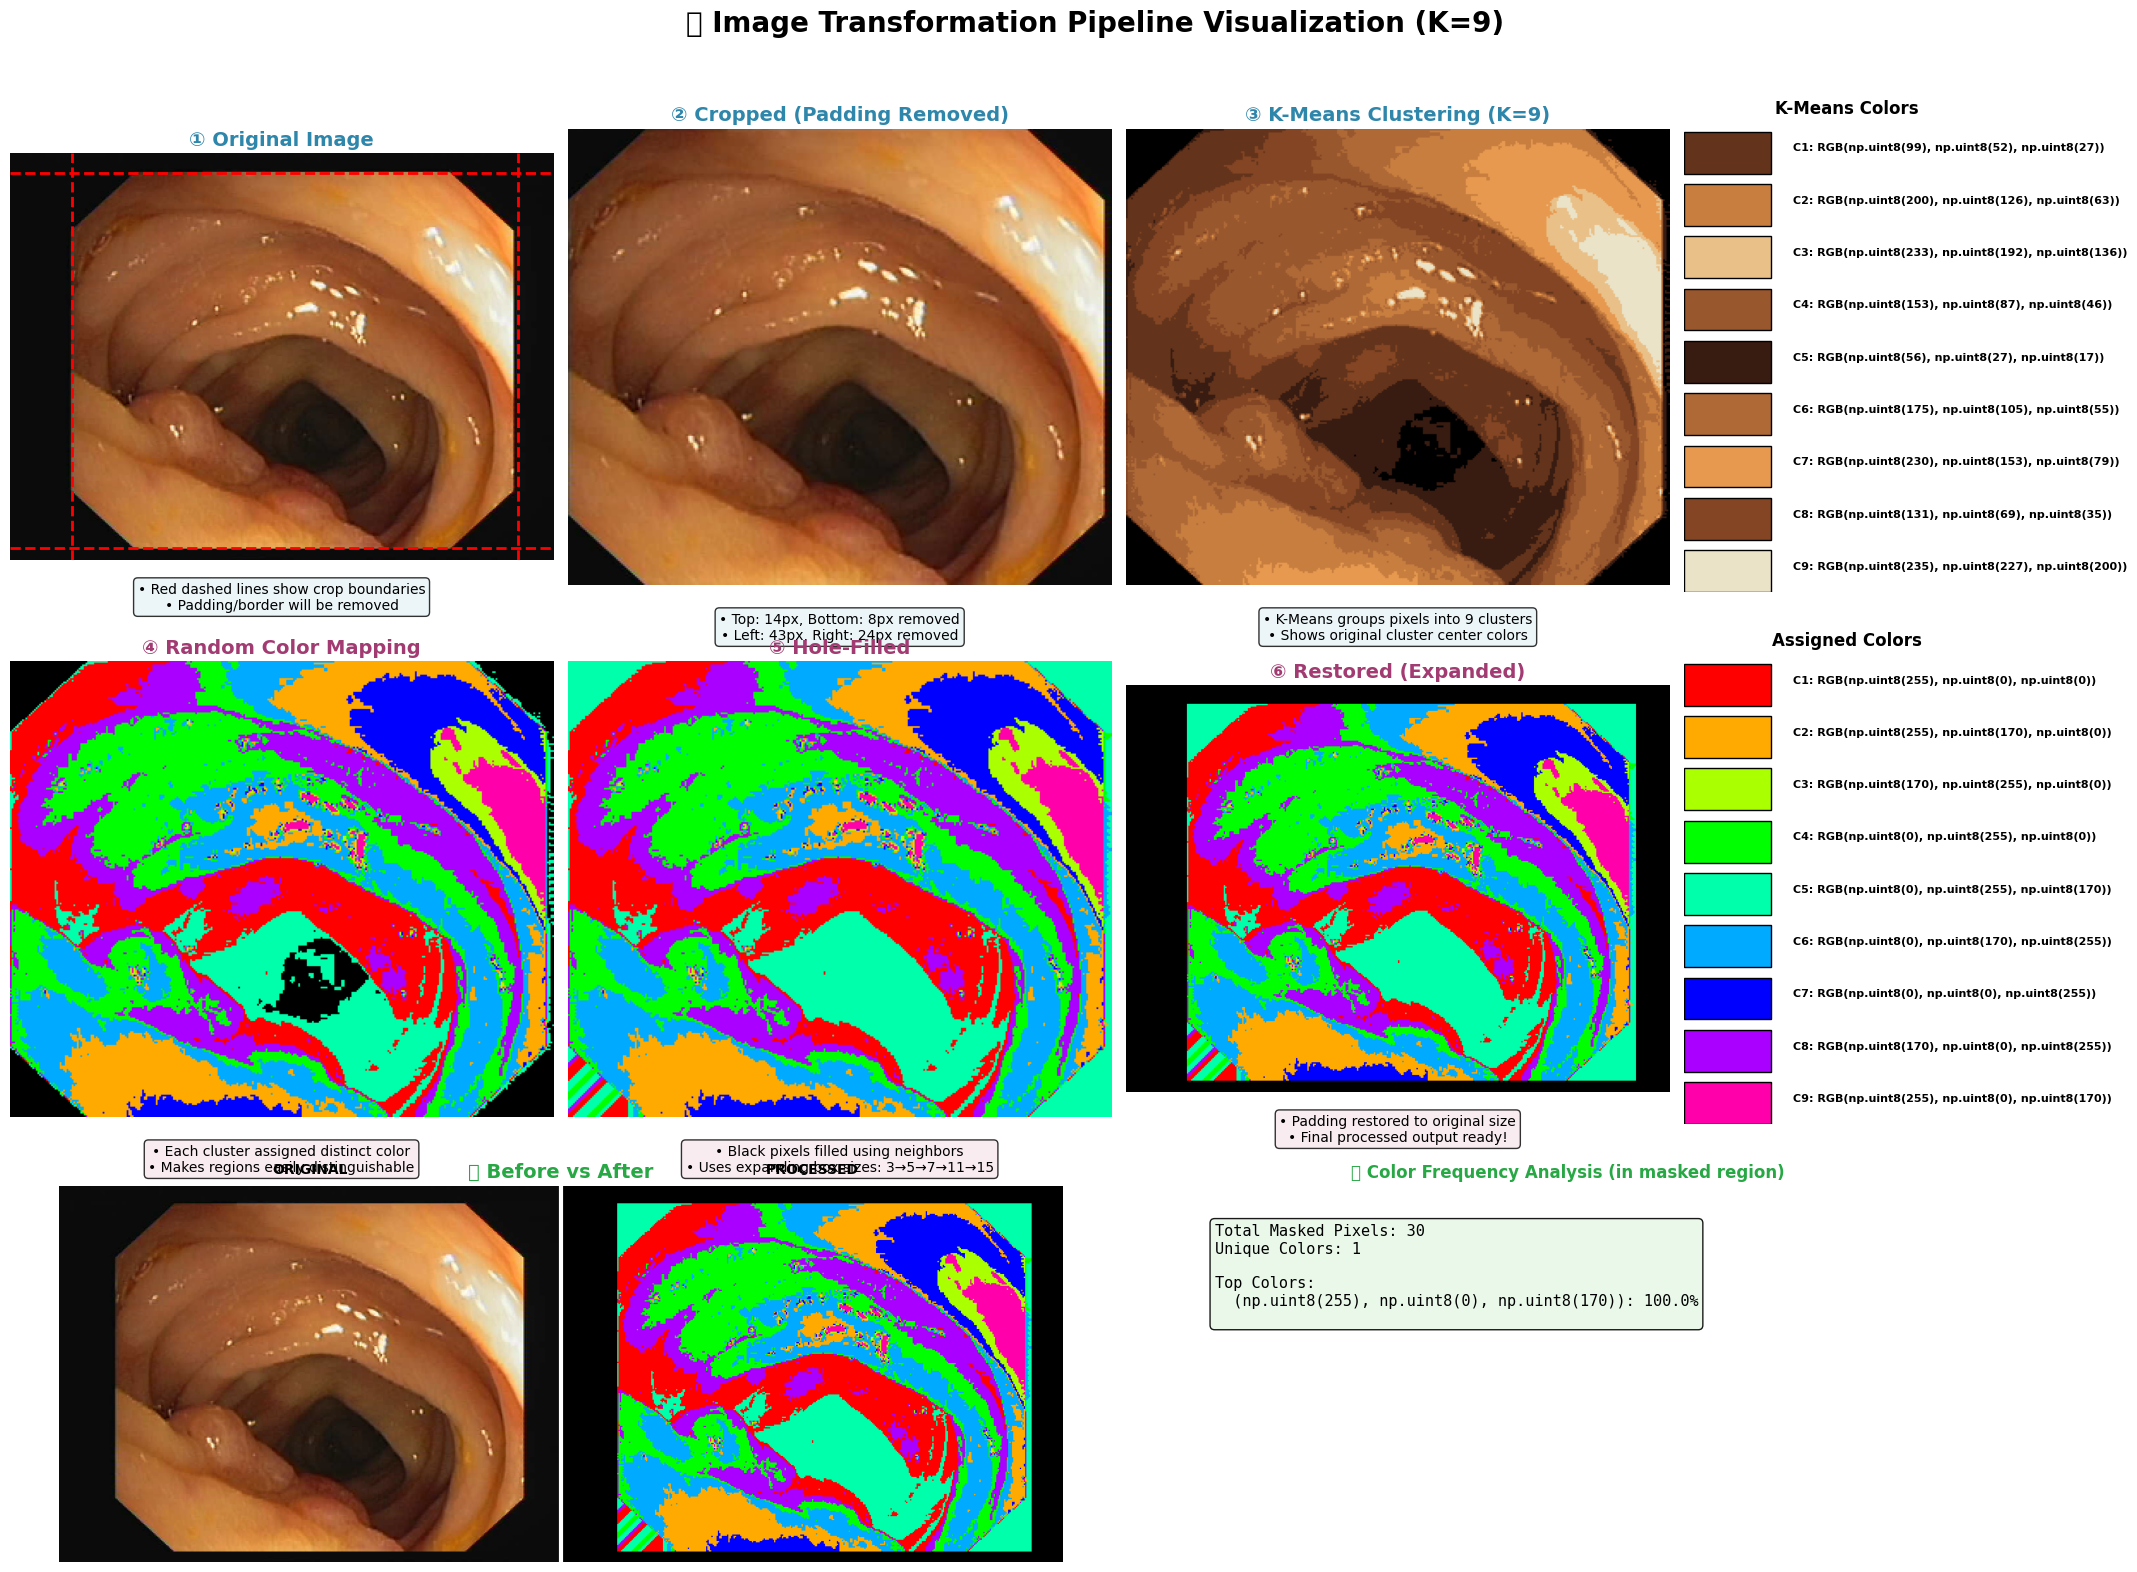


✅ Visualization saved to: transformation_pipeline_visualization.png


In [7]:
# ============================================
# BEAUTIFUL STEP-BY-STEP TRANSFORMATION VISUALIZATION
# ============================================

def visualize_complete_pipeline(input_path, output_folder='subcolr', k=9):
    """
    Beautiful visualization of the complete image transformation pipeline
    with annotations, arrows, descriptions, and frequency analysis.
    """
    from matplotlib.patches import FancyArrowPatch, Rectangle
    from matplotlib.gridspec import GridSpec
    
    # Step 1: Load original image
    original = load_image(input_path)
    
    # Step 2: Crop border / remove padding
    cropped, border_color, crop_bounds = crop_border(original)
    top, bottom, left, right = crop_bounds
    
    # Step 3: K-Means clustering
    labels, centers = kmeans_cluster(cropped, k, border_color)
    
    # Create image with original cluster center colors
    h, w = cropped.shape[:2]
    kmeans_original_colors = np.zeros((h*w, 3), dtype=np.uint8)
    for i in range(h*w):
        if labels[i] >= 0:
            kmeans_original_colors[i] = centers[labels[i]]
    kmeans_original_colors = kmeans_original_colors.reshape(h, w, 3)
    
    # Step 4: Generate random colors and create colored image
    random_colors = generate_random_colors(k)
    kmeans_colored = create_clustered_image(cropped.shape, labels, random_colors)
    
    # Step 5: Fill holes
    filled = fill_holes(kmeans_colored)
    
    # Step 6: Restore to original shape
    restored = restore_to_original_shape(filled, original.shape, crop_bounds)
    
    # Load predicted output if exists
    img_name = os.path.basename(input_path)
    output_path = os.path.join(output_folder, img_name)
    if os.path.exists(output_path):
        output_img = load_image(output_path)
    else:
        output_img = restored
    
    # Calculate frequency map
    h_out, w_out = output_img.shape[:2]
    white_mask = np.all(original > 240, axis=2)
    masked_pixels = output_img[white_mask]
    
    if len(masked_pixels) > 0:
        freq_map = Counter([tuple(p) for p in masked_pixels])
        freq_df = pd.DataFrame([
            {'RGB': str(color), 'Frequency': count, 'Percentage': round(count/len(masked_pixels)*100, 2)}
            for color, count in freq_map.most_common()
        ])
    else:
        freq_df = pd.DataFrame()
    
    # ========== CREATE BEAUTIFUL FIGURE ==========
    fig = plt.figure(figsize=(22, 16))
    gs = GridSpec(3, 4, figure=fig, height_ratios=[1, 1, 0.8], width_ratios=[1, 1, 1, 0.6])
    
    fig.suptitle(f'🔬 Image Transformation Pipeline Visualization (K={k})', 
                 fontsize=20, fontweight='bold', y=0.98)
    
    # ====== ROW 1 ======
    # Step 1: Original with crop lines
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(original)
    # Draw crop boundary lines
    ax1.axhline(y=top, color='red', linestyle='--', linewidth=2, label='Crop boundary')
    ax1.axhline(y=bottom, color='red', linestyle='--', linewidth=2)
    ax1.axvline(x=left, color='red', linestyle='--', linewidth=2)
    ax1.axvline(x=right, color='red', linestyle='--', linewidth=2)
    ax1.set_title('① Original Image', fontsize=14, fontweight='bold', color='#2E86AB')
    ax1.axis('off')
    # Add text annotation
    ax1.text(0.5, -0.12, 
             '• Red dashed lines show crop boundaries\n• Padding/border will be removed',
             transform=ax1.transAxes, fontsize=10, ha='center', 
             bbox=dict(boxstyle='round', facecolor='#E8F4F8', alpha=0.8))
    
    # Step 2: Cropped (padding removed)
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(cropped)
    ax2.set_title('② Cropped (Padding Removed)', fontsize=14, fontweight='bold', color='#2E86AB')
    ax2.axis('off')
    ax2.text(0.5, -0.12,
             f'• Top: {top}px, Bottom: {original.shape[0]-bottom-1}px removed\n• Left: {left}px, Right: {original.shape[1]-right-1}px removed',
             transform=ax2.transAxes, fontsize=10, ha='center',
             bbox=dict(boxstyle='round', facecolor='#E8F4F8', alpha=0.8))
    
    # Step 3: K-Means with original colors
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.imshow(kmeans_original_colors)
    ax3.set_title(f'③ K-Means Clustering (K={k})', fontsize=14, fontweight='bold', color='#2E86AB')
    ax3.axis('off')
    ax3.text(0.5, -0.12,
             f'• K-Means groups pixels into {k} clusters\n• Shows original cluster center colors',
             transform=ax3.transAxes, fontsize=10, ha='center',
             bbox=dict(boxstyle='round', facecolor='#E8F4F8', alpha=0.8))
    
    # K-Means color palette (right side)
    ax_colors = fig.add_subplot(gs[0, 3])
    ax_colors.set_title('K-Means Colors', fontsize=12, fontweight='bold')
    ax_colors.axis('off')
    for i, center in enumerate(centers):
        rect = plt.Rectangle((0, 1 - (i+1)/k), 0.4, 0.8/k, 
                             facecolor=center/255, edgecolor='black', linewidth=1)
        ax_colors.add_patch(rect)
        ax_colors.text(0.5, 1 - (i+0.5)/k, f'C{i+1}: RGB{tuple(center)}', 
                      fontsize=8, va='center', fontweight='bold')
    ax_colors.set_xlim(0, 1.5)
    ax_colors.set_ylim(0, 1)
    
    # ====== ROW 2 ======
    # Step 4: Random color mapping
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.imshow(kmeans_colored)
    ax4.set_title('④ Random Color Mapping', fontsize=14, fontweight='bold', color='#A23B72')
    ax4.axis('off')
    ax4.text(0.5, -0.12,
             '• Each cluster assigned distinct color\n• Makes regions easily distinguishable',
             transform=ax4.transAxes, fontsize=10, ha='center',
             bbox=dict(boxstyle='round', facecolor='#F8E8EE', alpha=0.8))
    
    # Step 5: Hole-filled
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.imshow(filled)
    ax5.set_title('⑤ Hole-Filled', fontsize=14, fontweight='bold', color='#A23B72')
    ax5.axis('off')
    ax5.text(0.5, -0.12,
             '• Black pixels filled using neighbors\n• Uses expanding box sizes: 3→5→7→11→15',
             transform=ax5.transAxes, fontsize=10, ha='center',
             bbox=dict(boxstyle='round', facecolor='#F8E8EE', alpha=0.8))
    
    # Step 6: Restored/Expanded
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.imshow(restored)
    ax6.set_title('⑥ Restored (Expanded)', fontsize=14, fontweight='bold', color='#A23B72')
    ax6.axis('off')
    ax6.text(0.5, -0.12,
             '• Padding restored to original size\n• Final processed output ready!',
             transform=ax6.transAxes, fontsize=10, ha='center',
             bbox=dict(boxstyle='round', facecolor='#F8E8EE', alpha=0.8))
    
    # Random color palette (right side)
    ax_rcolors = fig.add_subplot(gs[1, 3])
    ax_rcolors.set_title('Assigned Colors', fontsize=12, fontweight='bold')
    ax_rcolors.axis('off')
    for i, color in enumerate(random_colors):
        rect = plt.Rectangle((0, 1 - (i+1)/k), 0.4, 0.8/k,
                             facecolor=np.array(color)/255, edgecolor='black', linewidth=1)
        ax_rcolors.add_patch(rect)
        ax_rcolors.text(0.5, 1 - (i+0.5)/k, f'C{i+1}: RGB{color}',
                       fontsize=8, va='center', fontweight='bold')
    ax_rcolors.set_xlim(0, 1.5)
    ax_rcolors.set_ylim(0, 1)
    
    # ====== ROW 3: RESULTS ======
    # Final output comparison
    ax_final = fig.add_subplot(gs[2, 0:2])
    ax_final.imshow(np.hstack([original, output_img]))
    ax_final.set_title('📊 Before vs After', fontsize=14, fontweight='bold', color='#28A745')
    ax_final.axvline(x=original.shape[1], color='white', linestyle='-', linewidth=3)
    ax_final.text(original.shape[1]//2, -10, 'ORIGINAL', fontsize=10, ha='center', fontweight='bold')
    ax_final.text(original.shape[1] + output_img.shape[1]//2, -10, 'PROCESSED', fontsize=10, ha='center', fontweight='bold')
    ax_final.axis('off')
    
    # Frequency analysis
    ax_freq = fig.add_subplot(gs[2, 2:])
    ax_freq.axis('off')
    ax_freq.set_title('📈 Color Frequency Analysis (in masked region)', fontsize=12, fontweight='bold', color='#28A745')
    
    if not freq_df.empty:
        # Create bar chart data
        top_colors = freq_df.head(6)
        y_pos = np.arange(len(top_colors))
        
        freq_text = f"Total Masked Pixels: {len(masked_pixels)}\n"
        freq_text += f"Unique Colors: {len(freq_df)}\n\n"
        freq_text += "Top Colors:\n"
        for idx, row in top_colors.iterrows():
            freq_text += f"  {row['RGB']}: {row['Percentage']:.1f}%\n"
        
        if len(freq_df) >= 3:
            top3_sum = freq_df.head(3)['Percentage'].sum()
            freq_text += f"\n🎯 TOP 3 COMBINED: {top3_sum:.1f}%"
        
        ax_freq.text(0.1, 0.9, freq_text, transform=ax_freq.transAxes, fontsize=11,
                    va='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='#E8F8E8', alpha=0.9))
    
    # Add arrows between steps
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Save the figure
    save_path = 'transformation_pipeline_visualization.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f'\n✅ Visualization saved to: {save_path}')
    return fig

# ============================================
# RUN THE VISUALIZATION
# ============================================
input_folder = 'subi'
images = sorted([f for f in os.listdir(input_folder) if f.endswith('.png')], 
                key=lambda x: int(x.split('.')[0]))

if images:
    sample_img = random.choice(images)
    sample_path = os.path.join(input_folder, sample_img)
    print(f'🖼️ Visualizing: {sample_img}\n')
    print('=' * 50)
    visualize_complete_pipeline(sample_path, k=K)
else:
    print('❌ No images found in subi folder!')